In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import classification_report,precision_recall_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
import gc
import warnings
import time

warnings.filterwarnings("ignore")
color_pal = sns.color_palette()
plt.style.use("ggplot")

In [21]:
df = pd.read_parquet("./train_data.parquet")
df.head()

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674,0
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217,0
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603,0
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600,0
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827,0


# Data Exploration

Text(0, 0.5, 'Percentage')

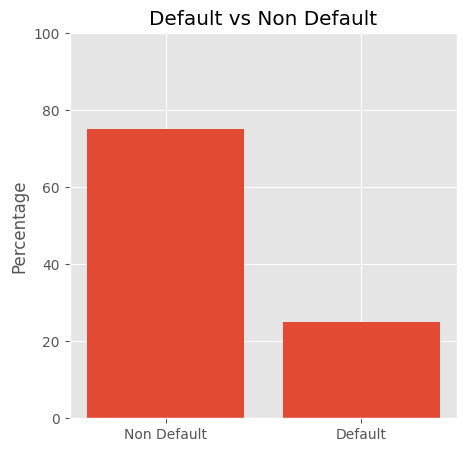

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.bar(["Non Default", "Default"], df["target"].value_counts()/len(df) * 100)
plt.title("Default vs Non Default")
ax.set_ylim(ymax=100)
ax.set_ylabel("Percentage")

# Preprocessing and Feature Engineering

In [23]:
# https://www.kaggle.com/code/huseyincot/amex-agg-data-how-it-created/notebook

def preprocess(df):

    df = df.drop(columns = "S_2")

    all_features = df.drop(columns=["customer_ID", "target"], errors="ignore").columns

    categorical_features = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
    
    numerical_features = [col for col in all_features if col not in categorical_features]

    # Group numerical features by ID, and calculate mean, std, min and max of the features
    train_num_agg = df.groupby("customer_ID")[numerical_features].agg(["mean", "std", "min", "max", "last"])
    train_num_agg.columns = ["_".join(x) for x in train_num_agg.columns]
    train_num_agg.head()

    # Group categorical features by ID, and count and number of unique entries
    train_cat_agg = df.groupby("customer_ID")[categorical_features].agg(["count", "nunique"])
    train_cat_agg.columns = ["_".join(x) for x in train_cat_agg.columns]
    train_cat_agg.head()

    # Combined features
    df_features = pd.concat([train_num_agg, train_cat_agg], axis=1)
    df_target = None

    # For each ID get the last target value so size target == size df features
    if "target" in df.columns:
        df_target = df.groupby("customer_ID").agg(["last"])["target"]

    return df_features, df_target

    

In [24]:
X, y = preprocess(df)

KeyboardInterrupt: 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [12]:
# Kaggel evaluation metric
def amex_metric(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:

    def top_four_percent_captured(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        df = (pd.concat([y_true, y_pred], axis='columns')
              .sort_values('prediction', ascending=False))
        df['weight'] = df['target'].apply(lambda x: 20 if x==0 else 1)
        four_pct_cutoff = int(0.04 * df['weight'].sum())
        df['weight_cumsum'] = df['weight'].cumsum()
        df_cutoff = df.loc[df['weight_cumsum'] <= four_pct_cutoff]
        return (df_cutoff['target'] == 1).sum() / (df['target'] == 1).sum()
        
    def weighted_gini(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        df = (pd.concat([y_true, y_pred], axis='columns')
              .sort_values('prediction', ascending=False))
        df['weight'] = df['target'].apply(lambda x: 20 if x==0 else 1)
        df['random'] = (df['weight'] / df['weight'].sum()).cumsum()
        total_pos = (df['target'] * df['weight']).sum()
        df['cum_pos_found'] = (df['target'] * df['weight']).cumsum()
        df['lorentz'] = df['cum_pos_found'] / total_pos
        df['gini'] = (df['lorentz'] - df['random']) * df['weight']
        return df['gini'].sum()

    def normalized_weighted_gini(y_true: pd.DataFrame, y_pred: pd.DataFrame) -> float:
        y_true_pred = y_true.rename(columns={'target': 'prediction'})
        return weighted_gini(y_true, y_pred) / weighted_gini(y_true, y_true_pred)

    g = normalized_weighted_gini(y_true, y_pred)
    d = top_four_percent_captured(y_true, y_pred)

    return 0.5 * (g + d)

# Hyperparameter Searcher

In [34]:
from sklearn.metrics import make_scorer

def amex_metric_proba(y_true, y_pred):
    target_df = pd.DataFrame(y_true, index=y_true.index).rename({ "last": "target"}, axis="columns")
    pred_df = pd.DataFrame(data={ "prediction": y_pred }, index=y_true.index) 

    return amex_metric(target_df, pred_df)
    
custom_scorer = make_scorer(amex_metric_proba, needs_proba=True)

param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.1, 0.01, 0.001],
    'objective': ["binary:logistic"],
    'enable_categorical': [True],
    'device': ['cuda']
}

model = xgb.XGBClassifier()

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=custom_scorer,
    cv=3,
    verbose=3,
    n_jobs=1
)

grid_search.fit(X_train[:10000], y_train[:10000])

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=100, objective=binary:logistic;, score=0.767 total time=   5.8s
[CV 2/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=100, objective=binary:logistic;, score=0.751 total time=   5.2s
[CV 3/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=100, objective=binary:logistic;, score=0.756 total time=   5.2s
[CV 1/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=500, objective=binary:logistic;, score=0.769 total time=  19.7s
[CV 2/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=500, objective=binary:logistic;, score=0.758 total time=  19.8s
[CV 3/3] END device=cuda, enable_categorical=True, learning_rate=0.1, n_estimators=500, objective=binary:logistic;, score=0.755 total time=  19.6s
[CV 1/3] END device=cuda, enable_categorical=True, learnin

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=1,
             param_grid={'device': ['cuda'], 'enable_categorical': [True],
                         'learning_rate': [0.1, 0.01, 0.001],
                         'n_estimators': [100, 500, 1000],
                         'objective': ['binary:logistic']},
             scoring=make_scorer(amex_metric_proba, response_method='predict_proba'),
             verbose=3)

In [35]:
print(f"Best score: {grid_search.best_score_:.3f}")
print(f"Best parameters: {grid_search.best_params_}")

Best score: 0.763
Best parameters: {'device': 'cuda', 'enable_categorical': True, 'learning_rate': 0.1, 'n_estimators': 1000, 'objective': 'binary:logistic'}


# Train Model

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True)
model = xgb.XGBClassifier(
        n_estimators=1000,
        objective="binary:logistic", 
        learning_rate=0.1, 
        early_stopping_rounds=10,
        enable_categorical=True, # as we have categorical variables
        device="cuda")

train_time = []
for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    print(f"{'#' * 5} Fold {i + 1} {'#' * 5}")
    start_time = time.time()

    X_train_fold, y_train_fold = X_train.iloc[train_index, :], y_train.iloc[train_index]
    X_val_fold, y_val_fold = X_train.iloc[test_index, :], y_train.iloc[test_index]
    
    model.fit(X_train_fold, y_train_fold,
             eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
             verbose=100)

    pred_proba = model.predict_proba(X_val_fold)[:, 1]

    training_time = time.time() - start_time
    
    train_time.append(training_time)

    print(classification_report(y_val_fold, pred_proba.round()))
    
    precision, recall, _ = precision_recall_curve(y_val_fold, pred_proba)
    
    print(f"PR-AUC Score: {auc(recall, precision)} | Train Time: {training_time}\n")

    del X_train_fold, y_train_fold, X_val_fold, y_val_fold
    gc.collect()

##### Fold 1 #####
[0]	validation_0-logloss:0.52138	validation_1-logloss:0.52172
[100]	validation_0-logloss:0.19950	validation_1-logloss:0.22418
[200]	validation_0-logloss:0.17751	validation_1-logloss:0.22190
[247]	validation_0-logloss:0.16906	validation_1-logloss:0.22177
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     54414
           1       0.81      0.82      0.81     19012

    accuracy                           0.90     73426
   macro avg       0.87      0.87      0.87     73426
weighted avg       0.90      0.90      0.90     73426

PR-AUC Score: 0.8947878389850834 | Train Time: 172.28214764595032

##### Fold 2 #####
[0]	validation_0-logloss:0.52145	validation_1-logloss:0.52173
[100]	validation_0-logloss:0.19997	validation_1-logloss:0.22396
[190]	validation_0-logloss:0.17933	validation_1-logloss:0.22210
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     54414
           1   

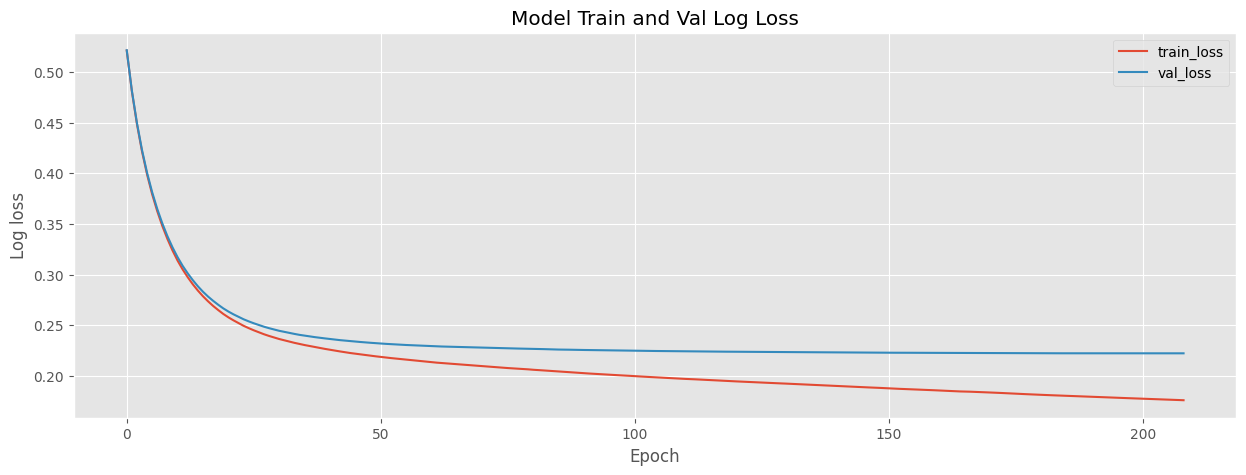

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))

plt.plot(np.arange(0, len(model.evals_result()["validation_0"]["logloss"])), model.evals_result()["validation_0"]["logloss"], label="train_loss")
plt.plot(np.arange(0, len(model.evals_result()["validation_1"]["logloss"])), model.evals_result()["validation_1"]["logloss"], label="val_loss")
plt.legend()
plt.title("Model Train and Val Log Loss")
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.savefig("xgboost_loss.pdf", bbox_inches='tight', format="pdf")

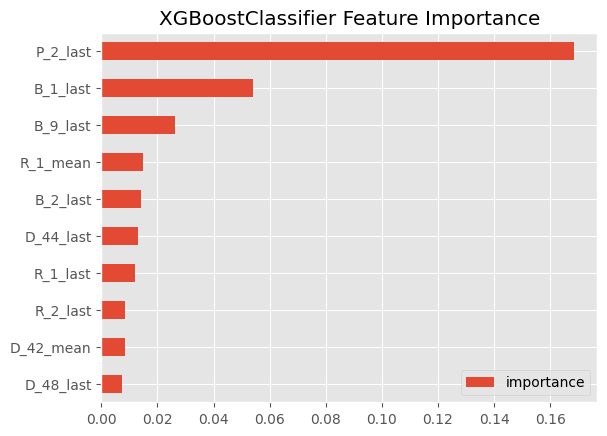

In [16]:
fi = pd.DataFrame(data=model.feature_importances_, index=model.feature_names_in_, columns=["importance"]).sort_values("importance")[-10:]
fig = fi.plot(kind="barh", title="XGBoostClassifier Feature Importance")
fig.get_figure().savefig("xgboost_10feature_importance.pdf", bbox_inches='tight', format="pdf")


In [17]:
pred = model.predict_proba(X_test)

In [18]:
target_df = pd.DataFrame(y_test, index=y_test.index).rename({ "last": "target"}, axis="columns")
pred_df = pd.DataFrame(data={ "prediction": pred[:, 1] }, index=y_test.index)

In [19]:
amex_metric(target_df, pred_df)

0.7909129043702637

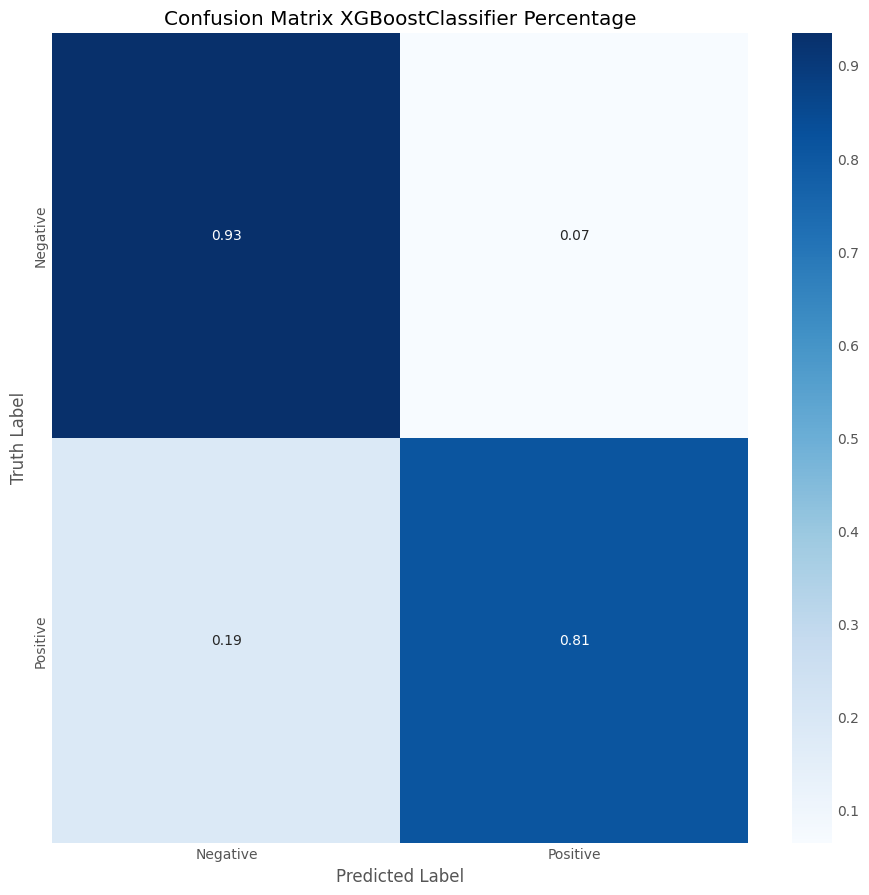

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 10))
binary_preds = (pred[:, 1] >= 0.5).astype(int)
cm = confusion_matrix(y_test, binary_preds, normalize="true")
# cm = cm.astype('float') / cm.sum(keepdims=True) * 100
sns.heatmap(cm, annot=True, ax=ax, xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"], cmap="Blues", fmt=".2f")
plt.xlabel("Predicted Label")
plt.ylabel("Truth Label")
plt.title("Confusion Matrix XGBoostClassifier Percentage")
plt.savefig("cfm.pdf", format="pdf", bbox_inches="tight")
plt.show()